# Graph Layout Optimization — GNN + PPO Pipeline
## Ginger Agents — CS5180 Spring 2026
**Team:** Weiyi Mao, Hui Kong

### Pipeline:
1. Train GCN on crossing prediction → extract learned embeddings
2. Train PPO with learned embeddings
3. Evaluate on test set (SPC metric)
4. Visualize results

### Key improvement over previous version:
- **Before:** Hand-crafted features (degree, clustering, etc.) — no learning
- **Now:** GCN trained to predict which nodes cause crossings → learned 32-dim embeddings

## 0. Setup

In [1]:
import os
import random
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from stable_baselines3 import PPO
from env_fixed import GraphLayoutEnvFixed, MAX_NODES
from xing import XingLoss

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

rome_dir = "./rome"
print(f"PyTorch: {torch.__version__}")
print(f"Working dir: {os.getcwd()}")

PyTorch: 2.7.0
Working dir: /Users/mao/Downloads


---
## 1. GCN Model Definition

A 3-layer GCN that predicts per-node crossing contribution.
The hidden layer representations = **learned topology embeddings**.

$$H^{(l+1)} = \sigma(\hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2} H^{(l)} W^{(l)})$$

In [2]:
class GCNLayer(nn.Module):
    """Simple GCN layer: H' = D^{-1/2} A D^{-1/2} H W"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, adj_norm):
        return adj_norm @ self.linear(x)


class CrossingGCN(nn.Module):
    """
    3-layer GCN that predicts per-node crossing contribution.
    Hidden representations = learned topology embeddings.
    """
    def __init__(self, in_dim=9, hidden_dim=32, num_layers=3):
        super().__init__()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()

        for i in range(num_layers):
            in_ch = in_dim if i == 0 else hidden_dim
            self.layers.append(GCNLayer(in_ch, hidden_dim))
            self.norms.append(nn.LayerNorm(hidden_dim))

        self.pred_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, adj_norm):
        h = x
        for layer, norm in zip(self.layers, self.norms):
            h = layer(h, adj_norm)
            h = norm(h)
            h = F.relu(h)
        pred = self.pred_head(h).squeeze(-1)
        return h, pred

    def get_embeddings(self, x, adj_norm):
        with torch.no_grad():
            h = x
            for layer, norm in zip(self.layers, self.norms):
                h = layer(h, adj_norm)
                h = norm(h)
                h = F.relu(h)
        return h

print("GCN model defined.")
total_params = sum(p.numel() for p in CrossingGCN().parameters())
print(f"  Parameters: {total_params:,}")

GCN model defined.
  Parameters: 3,713


---
## 2. Helper Functions

In [3]:
def compute_node_features(G, coords, num_nodes):
    """Compute 9 input features per node for GCN."""
    nodes = list(range(num_nodes))
    c = coords.copy()
    c -= c.mean(axis=0)
    max_abs = np.abs(c).max()
    if max_abs > 1e-6:
        c /= max_abs

    degrees = np.array([G.degree(v) for v in nodes], dtype=np.float32)
    max_deg = degrees.max()
    norm_deg = degrees / max_deg if max_deg > 0 else degrees

    cc = nx.clustering(G)
    clust = np.array([cc.get(v, 0.0) for v in nodes], dtype=np.float32)

    bc = nx.betweenness_centrality(G)
    between = np.array([bc.get(v, 0.0) for v in nodes], dtype=np.float32)

    try:
        pr = nx.pagerank(G, max_iter=100)
    except:
        pr = {v: 1.0 / num_nodes for v in nodes}
    pagerank = np.array([pr.get(v, 0.0) for v in nodes], dtype=np.float32)
    pr_max = pagerank.max()
    if pr_max > 0:
        pagerank /= pr_max

    local_dens = np.zeros(num_nodes, dtype=np.float32)
    for v in nodes:
        neighbors = list(G.neighbors(v))
        k = len(neighbors)
        if k >= 2:
            subg = G.subgraph(neighbors)
            local_dens[v] = subg.number_of_edges() / (k * (k - 1) / 2)

    triangles = nx.triangles(G)
    tri = np.array([triangles.get(v, 0) for v in nodes], dtype=np.float32)
    tri_max = tri.max()
    if tri_max > 0:
        tri /= tri_max

    num_edges_norm = np.full(num_nodes, G.number_of_edges() / 100.0, dtype=np.float32)

    features = np.stack([
        c[:, 0], c[:, 1], norm_deg, clust, between, pagerank, local_dens, tri, num_edges_norm
    ], axis=1)
    return torch.tensor(features, dtype=torch.float32)


def direction(pi, pj, pk):
    return (pk[0] - pi[0]) * (pj[1] - pi[1]) - (pj[0] - pi[0]) * (pk[1] - pi[1])


def segments_intersect(p1, p2, p3, p4):
    d1 = direction(p3, p4, p1)
    d2 = direction(p3, p4, p2)
    d3 = direction(p1, p2, p3)
    d4 = direction(p1, p2, p4)
    if ((d1 > 0 and d2 < 0) or (d1 < 0 and d2 > 0)) and \
       ((d3 > 0 and d4 < 0) or (d3 < 0 and d4 > 0)):
        return True
    return False


def compute_crossing_labels(G, coords):
    """For each node, count how many crossings involve its edges."""
    num_nodes = G.number_of_nodes()
    node_crossings = np.zeros(num_nodes, dtype=np.float32)
    edges = list(G.edges())
    coords_np = coords if isinstance(coords, np.ndarray) else coords.numpy()

    for i in range(len(edges)):
        for j in range(i + 1, len(edges)):
            e1, e2 = edges[i], edges[j]
            if set(e1) & set(e2):
                continue
            p1, p2 = coords_np[e1[0]], coords_np[e1[1]]
            p3, p4 = coords_np[e2[0]], coords_np[e2[1]]
            if segments_intersect(p1, p2, p3, p4):
                node_crossings[e1[0]] += 1
                node_crossings[e1[1]] += 1
                node_crossings[e2[0]] += 1
                node_crossings[e2[1]] += 1

    max_c = node_crossings.max()
    if max_c > 0:
        node_crossings /= max_c
    return torch.tensor(node_crossings, dtype=torch.float32)


def build_adj_normalized(G, num_nodes):
    """Normalized adjacency matrix with self-loops."""
    adj = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for u, v in G.edges():
        adj[u, v] = 1.0
        adj[v, u] = 1.0
    adj += np.eye(num_nodes)
    deg = adj.sum(axis=1)
    deg_inv_sqrt = np.where(deg > 0, deg ** (-0.5), 0.0)
    D_inv_sqrt = np.diag(deg_inv_sqrt)
    adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt
    return torch.tensor(adj_norm, dtype=torch.float32)


def prepare_graph(graph_path):
    """Load graph, compute features + crossing labels."""
    G = nx.read_graphml(graph_path)
    G = nx.convert_node_labels_to_integers(G, ordering="sorted")
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")

    num_nodes = G.number_of_nodes()
    if num_nodes > 100 or num_nodes < 5:
        return None

    pos = nx.nx_agraph.graphviz_layout(G, prog="neato")
    coords = np.array([[pos[v][0], pos[v][1]] for v in G.nodes()], dtype=np.float32)

    features = compute_node_features(G, coords, num_nodes)
    labels = compute_crossing_labels(G, coords)
    adj_norm = build_adj_normalized(G, num_nodes)

    return {
        "graph_name": os.path.basename(graph_path),
        "features": features,
        "labels": labels,
        "adj_norm": adj_norm,
        "coords": coords,
        "num_nodes": num_nodes,
        "num_edges": G.number_of_edges(),
        "G": G,
    }

print("Helper functions defined.")

Helper functions defined.


---
## 3. Load & Prepare Graphs for GCN Training

In [4]:
# Collect all graph paths
all_graph_paths = []
for fname in sorted(os.listdir(rome_dir)):
    if not fname.endswith(".graphml"):
        continue
    all_graph_paths.append(os.path.join(rome_dir, fname))

print(f"Total graphml files: {len(all_graph_paths)}")

# Prepare data (use first 2000 for GCN training, all for embedding)
MAX_TRAIN_GCN = 2000

print(f"\nPreparing graphs for GCN training (max {MAX_TRAIN_GCN})...")
print("(Computing features + crossing labels for each graph)\n")

all_data = []
for gpath in tqdm(all_graph_paths, desc="Loading graphs"):
    d = prepare_graph(gpath)
    if d is not None:
        all_data.append(d)

train_data_gcn = all_data[:MAX_TRAIN_GCN]
print(f"\nTotal valid graphs: {len(all_data)}")
print(f"GCN training set: {len(train_data_gcn)}")

Total graphml files: 11534

Preparing graphs for GCN training (max 2000)...
(Computing features + crossing labels for each graph)



Loading graphs:   0%|          | 0/11534 [00:00<?, ?it/s]


Total valid graphs: 11530
GCN training set: 2000


---
## 4. Train GCN

**Task:** Predict per-node crossing contribution
- Input: 9 node features + adjacency matrix
- Output: how much each node contributes to crossings
- The hidden layer learns a 32-dim embedding that encodes "crossing-prone" patterns

In [5]:
#Sound Notification Installment
import numpy as np
from IPython.display import Audio

# Train GCN
EPOCHS = 50
HIDDEN_DIM = 32
LR = 1e-3

gcn_model = CrossingGCN(in_dim=9, hidden_dim=HIDDEN_DIM, num_layers=3)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=LR)

print(f"Training GCN ({sum(p.numel() for p in gcn_model.parameters()):,} params)")
print(f"  {len(train_data_gcn)} graphs, {EPOCHS} epochs\n")

losses = []
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    random.shuffle(train_data_gcn)
    total_loss = 0.0
    n_graphs = 0

    for d in train_data_gcn:
        x = d["features"]
        adj = d["adj_norm"]
        labels = d["labels"]

        _, pred = gcn_model(x, adj)
        loss = F.mse_loss(pred, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_graphs += 1

    avg_loss = total_loss / n_graphs
    losses.append(avg_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  loss={avg_loss:.4f}")

gcn_train_time = time.time() - start_time
print(f"\nGCN training done in {gcn_train_time:.0f}s")

# Save model
torch.save(gcn_model.state_dict(), "gcn_model.pt")
print("GCN model saved → gcn_model.pt")

Training GCN (3,713 params)
  2000 graphs, 50 epochs

  Epoch   1/50  loss=0.0381
  Epoch   5/50  loss=0.0303
  Epoch  10/50  loss=0.0283
  Epoch  15/50  loss=0.0273
  Epoch  20/50  loss=0.0263
  Epoch  25/50  loss=0.0256
  Epoch  30/50  loss=0.0251
  Epoch  35/50  loss=0.0248
  Epoch  40/50  loss=0.0245
  Epoch  45/50  loss=0.0241
  Epoch  50/50  loss=0.0239

GCN training done in 72s
GCN model saved → gcn_model.pt


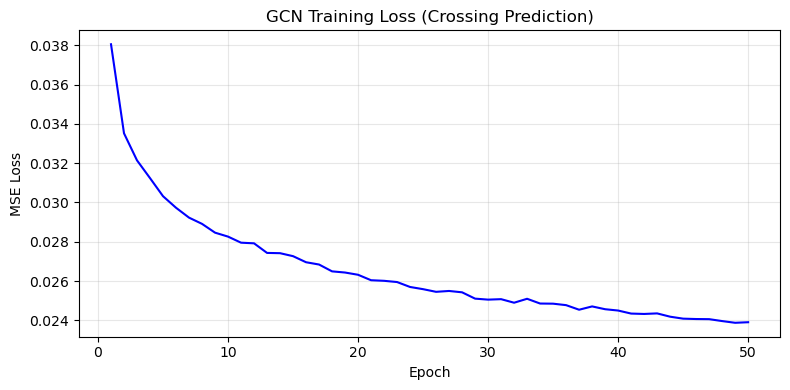

Final loss: 0.0239


In [6]:
# Plot GCN training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), losses, color="blue")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GCN Training Loss (Crossing Prediction)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("gcn_training_loss.png", dpi=150)
plt.show()
print(f"Final loss: {losses[-1]:.4f}")

---
## 5. Extract Learned Embeddings

Use the trained GCN's hidden layer to generate 32-dim embeddings for **all** graphs (train + test).

In [7]:
gcn_model.eval()
results = []

for d in tqdm(all_data, desc="Extracting embeddings"):
    x = d["features"]
    adj = d["adj_norm"]

    node_emb = gcn_model.get_embeddings(x, adj)  # [N, 32] LEARNED
    graph_emb = node_emb.mean(dim=0)              # [32]

    # Build edge_index
    edges = list(d["G"].edges())
    src = [e[0] for e in edges] + [e[1] for e in edges]
    dst = [e[1] for e in edges] + [e[0] for e in edges]
    edge_index = torch.tensor([src, dst], dtype=torch.long)

    coords_tensor = torch.tensor(d["coords"], dtype=torch.float32)

    # Compute crossings
    xing = XingLoss(d["G"], soft=False)
    crossings = xing(coords_tensor).item()

    results.append({
        "graph_name":  d["graph_name"],
        "node_emb":    node_emb,
        "graph_emb":   graph_emb,
        "edge_index":  edge_index,
        "coords":      coords_tensor,
        "num_nodes":   d["num_nodes"],
        "num_edges":   d["num_edges"],
        "y_crossings": torch.tensor(crossings, dtype=torch.float32),
    })

# Save — this REPLACES the old rome_embeddings.pt
torch.save(results, "rome_embeddings.pt")

print(f"\nSaved {len(results)} graphs → rome_embeddings.pt")
print(f"  Embedding dim: {results[0]['node_emb'].shape[1]} (LEARNED by GCN)")
print(f"  Old method: 7 hand-crafted features")
print(f"  New method: {HIDDEN_DIM}-dim GCN embeddings")

Extracting embeddings:   0%|          | 0/11530 [00:00<?, ?it/s]


Saved 11530 graphs → rome_embeddings.pt
  Embedding dim: 32 (LEARNED by GCN)
  Old method: 7 hand-crafted features
  New method: 32-dim GCN embeddings


---
## 6. Train PPO with Learned Embeddings

In [8]:
# Load embeddings
emb_data = torch.load("rome_embeddings.pt", weights_only=False)
emb_dict = {d["graph_name"]: {"node_emb": d["node_emb"], "graph_emb": d["graph_emb"]} for d in emb_data}
print(f"Loaded embeddings for {len(emb_dict)} graphs")
print(f"Embedding dim: {emb_data[0]['node_emb'].shape[1]}")

# Get training graph paths
train_paths = []
for fname in sorted(os.listdir(rome_dir)):
    if not fname.endswith(".graphml"):
        continue
    try:
        num = int(fname.split("grafo")[1].split(".")[0])
    except:
        continue
    if num > 9999:
        continue
    fpath = os.path.join(rome_dir, fname)
    G = nx.read_graphml(fpath)
    if G.number_of_nodes() <= MAX_NODES:
        train_paths.append(fpath)

print(f"Training graphs: {len(train_paths)}")

Loaded embeddings for 11530 graphs
Embedding dim: 32
Training graphs: 9872


In [9]:
# Create environment
env = GraphLayoutEnvFixed(
    train_paths,
    embeddings=emb_dict,
    max_steps=300,
    move_scale=2.0,
    patience=50,
)

print(f"Observation space: {env.observation_space.shape}")
print(f"Action space: {env.action_space.shape}")

Observation space: (3403,)
Action space: (3,)


In [10]:
# Train PPO
TIMESTEPS = 2000000

model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    gamma=0.99,
    ent_coef=0.02,
    clip_range=0.2,
)

print(f"Training PPO for {TIMESTEPS:,} timesteps...")
print(f"Using GCN learned embeddings ({HIDDEN_DIM}-dim)")
model.learn(total_timesteps=TIMESTEPS)
model.save("ppo_fixed")
print("\nModel saved → ppo_fixed.zip")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training PPO for 2,000,000 timesteps...
Using GCN learned embeddings (32-dim)
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 54.9     |
|    ep_rew_mean     | 0.0838   |
| time/              |          |
|    fps             | 321      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 52.7        |
|    ep_rew_mean          | -1.36       |
| time/                   |             |
|    fps                  | 271         |
|    iterations           | 2           |
|    time_elapsed         | 15          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009427661 |
|    clip_fraction        

---
## 7. Evaluate on Test Set (SPC Metric)

$$SPC = 100\% \times \frac{1}{N_t} \sum_{i} \frac{D_i - G_i}{\max(D_i, G_i)}$$

- $D_i$ = PPO crossings, $G_i$ = neato crossings
- SPC < 0 = better than neato

In [11]:
# Load model
model = PPO.load("ppo_fixed")

# Get test graphs
test_paths = []
for fname in sorted(os.listdir(rome_dir)):
    if not fname.endswith(".graphml"):
        continue
    try:
        num = int(fname.split("grafo")[1].split(".")[0])
    except:
        continue
    if 10000 <= num <= 10100:
        fpath = os.path.join(rome_dir, fname)
        G = nx.read_graphml(fpath)
        if G.number_of_nodes() <= MAX_NODES:
            test_paths.append(fpath)

print(f"Test graphs: {len(test_paths)}")

Test graphs: 99


In [12]:
# Evaluate
eval_results = []

for gpath in tqdm(test_paths, desc="Evaluating"):
    graph_name = os.path.basename(gpath)

    env_test = GraphLayoutEnvFixed(
        [gpath], embeddings=emb_dict,
        max_steps=300, move_scale=2.0, patience=50,
    )

    obs, _ = env_test.reset()
    neato_c = env_test.initial_crossings
    history = [neato_c]

    done, truncated = False, False
    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env_test.step(action)
        history.append(info["crossings"])

    eval_results.append({
        "graph_name": graph_name,
        "neato": neato_c,
        "ppo_best": info["best_crossings"],
        "improvement": info["improvement"],
        "history": history,
    })

print(f"Evaluated {len(eval_results)} graphs")

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Evaluated 99 graphs


In [13]:
# Compute SPC
spc_values = []
for r in eval_results:
    denom = max(r["ppo_best"], r["neato"])
    if denom > 0:
        spc_values.append((r["ppo_best"] - r["neato"]) / denom)
    else:
        spc_values.append(0.0)

spc = 100.0 * np.mean(spc_values)

wins = sum(1 for r in eval_results if r["improvement"] > 0)
ties = sum(1 for r in eval_results if r["improvement"] == 0)
losses_count = sum(1 for r in eval_results if r["improvement"] < 0)

avg_neato = np.mean([r["neato"] for r in eval_results])
avg_ppo = np.mean([r["ppo_best"] for r in eval_results])

print("=" * 60)
print(f"  SPC = {spc:.2f}%  (negative = better than neato)")
print("=" * 60)
print(f"  Test graphs       : {len(eval_results)}")
print(f"  Wins / Ties / Loss: {wins} / {ties} / {losses_count}")
print(f"  Win rate          : {100 * wins / len(eval_results):.1f}%")
print(f"  Avg neato         : {avg_neato:.1f}")
print(f"  Avg PPO           : {avg_ppo:.1f}")
print("=" * 60)

  SPC = -0.33%  (negative = better than neato)
  Test graphs       : 99
  Wins / Ties / Loss: 6 / 93 / 0
  Win rate          : 6.1%
  Avg neato         : 29.1
  Avg PPO           : 29.0


In [14]:
# Per-graph results
print(f"{'Graph Name':<35} {'neato':>6} {'PPO':>6} {'Δ':>5} {'Status':>6}")
print("-" * 65)
for r in sorted(eval_results, key=lambda x: -x["improvement"]):
    imp = r["improvement"]
    status = "✓ WIN" if imp > 0 else ("= TIE" if imp == 0 else "✗ LOSS")
    print(f"{r['graph_name']:<35} {int(r['neato']):>6} {int(r['ppo_best']):>6} {int(imp):>+5} {status:>6}")

Graph Name                           neato    PPO     Δ Status
-----------------------------------------------------------------
grafo10072.97.graphml                  104    102    +2  ✓ WIN
grafo10042.39.graphml                   12     11    +1  ✓ WIN
grafo10049.39.graphml                    9      8    +1  ✓ WIN
grafo10074.90.graphml                  136    135    +1  ✓ WIN
grafo10089.37.graphml                   12     11    +1  ✓ WIN
grafo10097.95.graphml                   38     37    +1  ✓ WIN
grafo10000.38.graphml                   11     11    +0  = TIE
grafo10001.32.graphml                    0      0    +0  = TIE
grafo10002.40.graphml                    4      4    +0  = TIE
grafo10003.40.graphml                   13     13    +0  = TIE
grafo10004.32.graphml                    4      4    +0  = TIE
grafo10005.39.graphml                   23     23    +0  = TIE
grafo10006.98.graphml                  125    125    +0  = TIE
grafo10007.31.graphml                    2      2   

---
## 8. Visualization

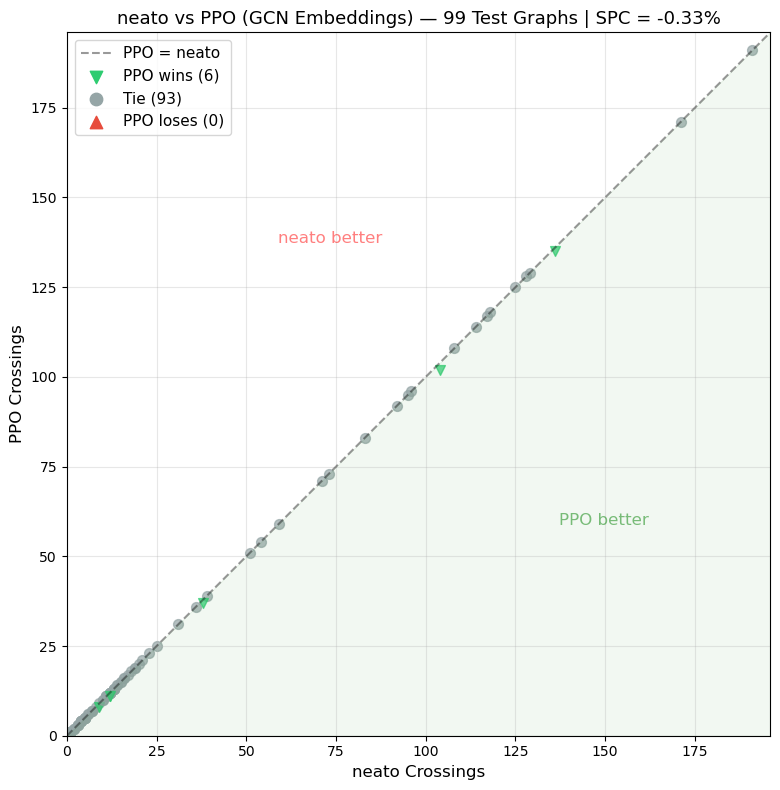

In [15]:
# PLOT 1: Scatter — neato vs PPO
fig, ax = plt.subplots(figsize=(8, 8))
max_val = max(max(r["neato"] for r in eval_results), max(r["ppo_best"] for r in eval_results)) + 5
ax.plot([0, max_val], [0, max_val], "k--", alpha=0.4, label="PPO = neato")

for r in eval_results:
    color = "#2ecc71" if r["improvement"] > 0 else ("#95a5a6" if r["improvement"] == 0 else "#e74c3c")
    marker = "v" if r["improvement"] > 0 else ("o" if r["improvement"] == 0 else "^")
    ax.scatter(r["neato"], r["ppo_best"], c=color, marker=marker, s=50, alpha=0.7)

ax.scatter([], [], c="#2ecc71", marker="v", s=80, label=f"PPO wins ({wins})")
ax.scatter([], [], c="#95a5a6", marker="o", s=80, label=f"Tie ({ties})")
ax.scatter([], [], c="#e74c3c", marker="^", s=80, label=f"PPO loses ({losses_count})")

ax.fill_between([0, max_val], [0, max_val], 0, alpha=0.05, color="green")
ax.text(max_val*0.7, max_val*0.3, "PPO better", fontsize=12, color="green", alpha=0.5)
ax.text(max_val*0.3, max_val*0.7, "neato better", fontsize=12, color="red", alpha=0.5)

ax.set_xlabel("neato Crossings", fontsize=12)
ax.set_ylabel("PPO Crossings", fontsize=12)
ax.set_title(f"neato vs PPO (GCN Embeddings) — {len(eval_results)} Test Graphs | SPC = {spc:.2f}%", fontsize=13)
ax.legend(fontsize=11)
ax.set_aspect("equal")
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("scatter_gcn_ppo.png", dpi=150)
plt.show()

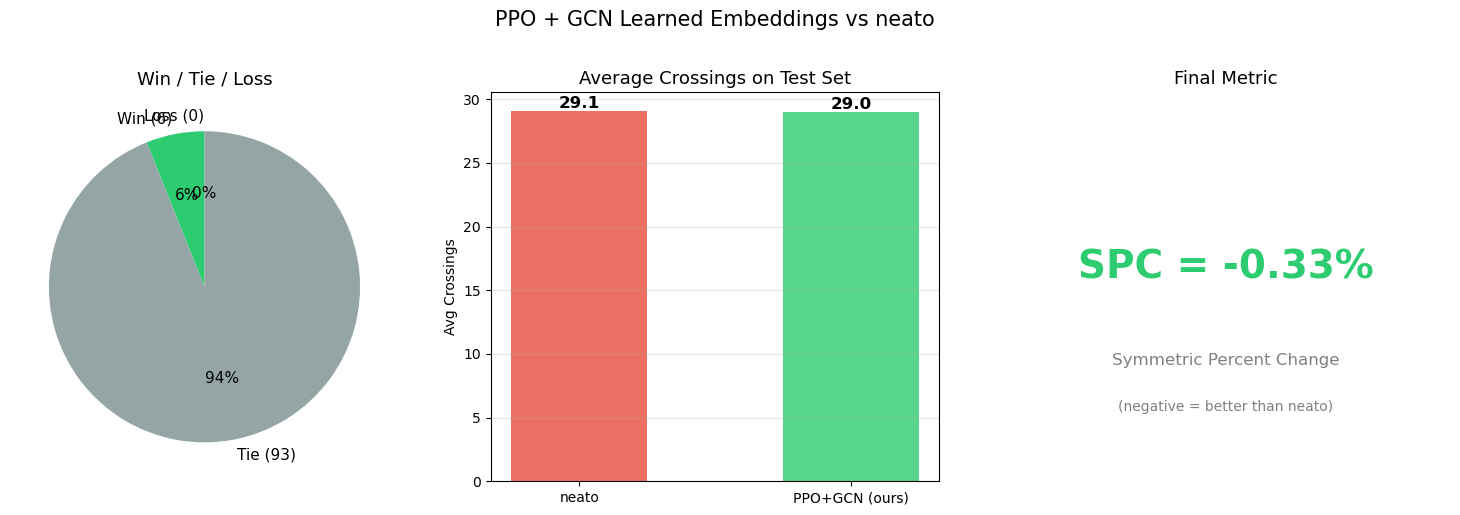

In [16]:
# PLOT 2: Summary — Pie + Bar + SPC
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie
ax = axes[0]
ax.pie([wins, ties, losses_count],
       labels=[f"Win ({wins})", f"Tie ({ties})", f"Loss ({losses_count})"],
       colors=["#2ecc71", "#95a5a6", "#e74c3c"],
       autopct="%1.0f%%", startangle=90, textprops={"fontsize": 11})
ax.set_title("Win / Tie / Loss", fontsize=13)

# Avg bar
ax = axes[1]
bars = ax.bar(["neato", "PPO+GCN (ours)"], [avg_neato, avg_ppo],
              color=["#e74c3c", "#2ecc71"], alpha=0.8, width=0.5)
for bar, val in zip(bars, [avg_neato, avg_ppo]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}", ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Avg Crossings")
ax.set_title("Average Crossings on Test Set", fontsize=13)
ax.grid(axis="y", alpha=0.3)

# SPC
ax = axes[2]
ax.text(0.5, 0.55, f"SPC = {spc:.2f}%", ha="center", va="center",
        fontsize=28, fontweight="bold",
        color="#2ecc71" if spc < 0 else "#e74c3c",
        transform=ax.transAxes)
ax.text(0.5, 0.3, "Symmetric Percent Change", ha="center",
        fontsize=12, color="gray", transform=ax.transAxes)
ax.text(0.5, 0.18, "(negative = better than neato)", ha="center",
        fontsize=10, color="gray", transform=ax.transAxes)
ax.axis("off")
ax.set_title("Final Metric", fontsize=13)

plt.suptitle("PPO + GCN Learned Embeddings vs neato", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("summary_gcn_results.png", dpi=150, bbox_inches="tight")
plt.show()

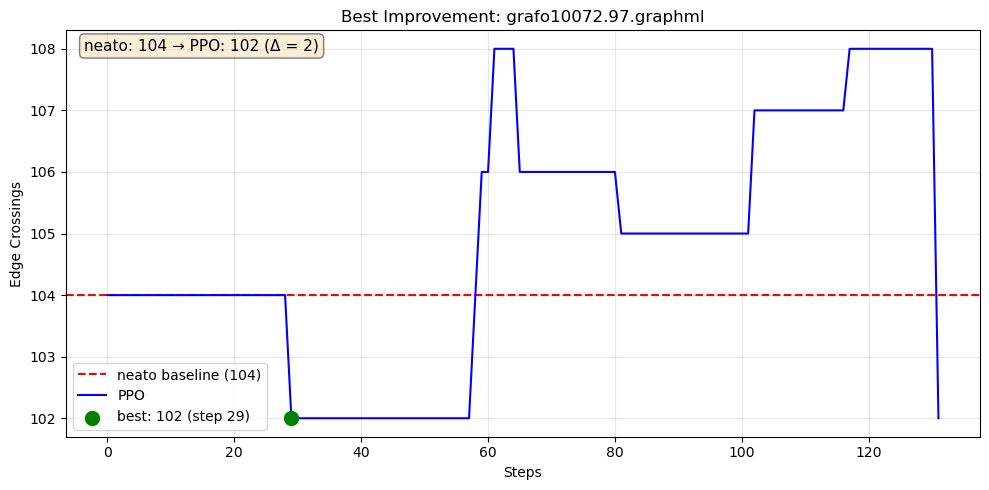

In [17]:
# PLOT 3: Best win trajectory
win_results = [r for r in eval_results if r["improvement"] > 0]

if win_results:
    best = max(win_results, key=lambda r: r["improvement"])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axhline(y=best["neato"], color="red", linestyle="--",
               label=f'neato baseline ({int(best["neato"])})')
    ax.plot(best["history"], label="PPO", color="blue")

    best_step = np.argmin(best["history"])
    best_val = best["history"][best_step]
    ax.scatter([best_step], [best_val], color="green", s=100, zorder=5,
               label=f"best: {int(best_val)} (step {best_step})")

    ax.set_xlabel("Steps")
    ax.set_ylabel("Edge Crossings")
    ax.set_title(f"Best Improvement: {best['graph_name']}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.98,
            f"neato: {int(best['neato'])} → PPO: {int(best['ppo_best'])} (Δ = {int(best['improvement'])})",
            transform=ax.transAxes, fontsize=11, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
    plt.tight_layout()
    plt.savefig("best_win_gcn.png", dpi=150)
    plt.show()
else:
    print("No wins to plot.")

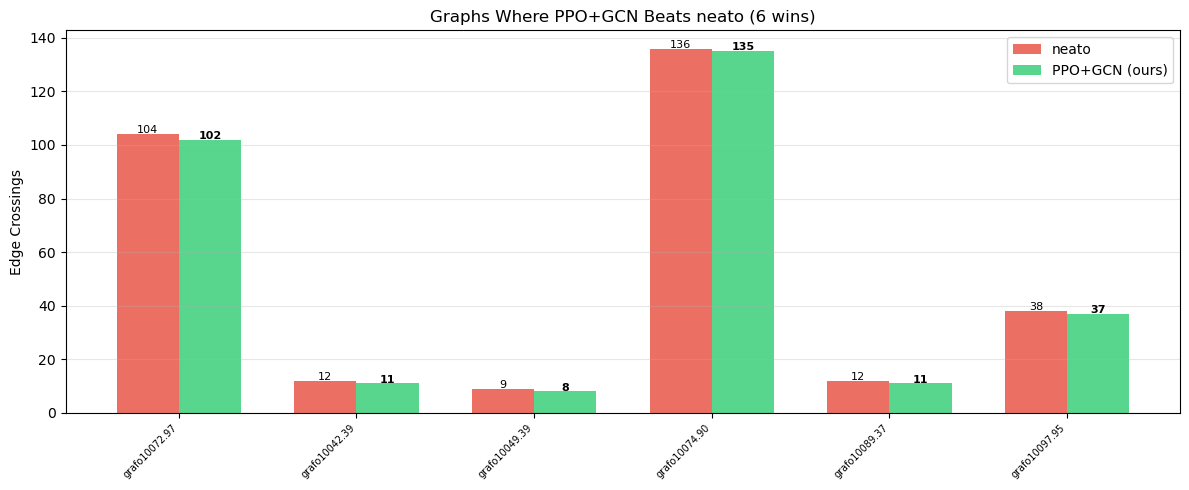

In [18]:
# PLOT 4: Bar chart of wins
if win_results:
    win_results_sorted = sorted(win_results, key=lambda x: -x["improvement"])
    fig, ax = plt.subplots(figsize=(12, 5))
    
    names = [r["graph_name"].replace(".graphml", "") for r in win_results_sorted]
    neato_vals = [r["neato"] for r in win_results_sorted]
    ppo_vals = [r["ppo_best"] for r in win_results_sorted]
    
    x = np.arange(len(names))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, neato_vals, width, label="neato", color="#e74c3c", alpha=0.8)
    bars2 = ax.bar(x + width/2, ppo_vals, width, label="PPO+GCN (ours)", color="#2ecc71", alpha=0.8)
    
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{int(bar.get_height())}", ha="center", fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{int(bar.get_height())}", ha="center", fontsize=8, fontweight="bold")
    
    ax.set_ylabel("Edge Crossings")
    ax.set_title(f"Graphs Where PPO+GCN Beats neato ({len(win_results)} wins)")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("wins_bar_gcn.png", dpi=150)
    plt.show()
else:
    print("No wins to plot.")

---
## 9. Comparison: Hand-crafted vs GCN Embeddings

Fill in results below after running both versions:

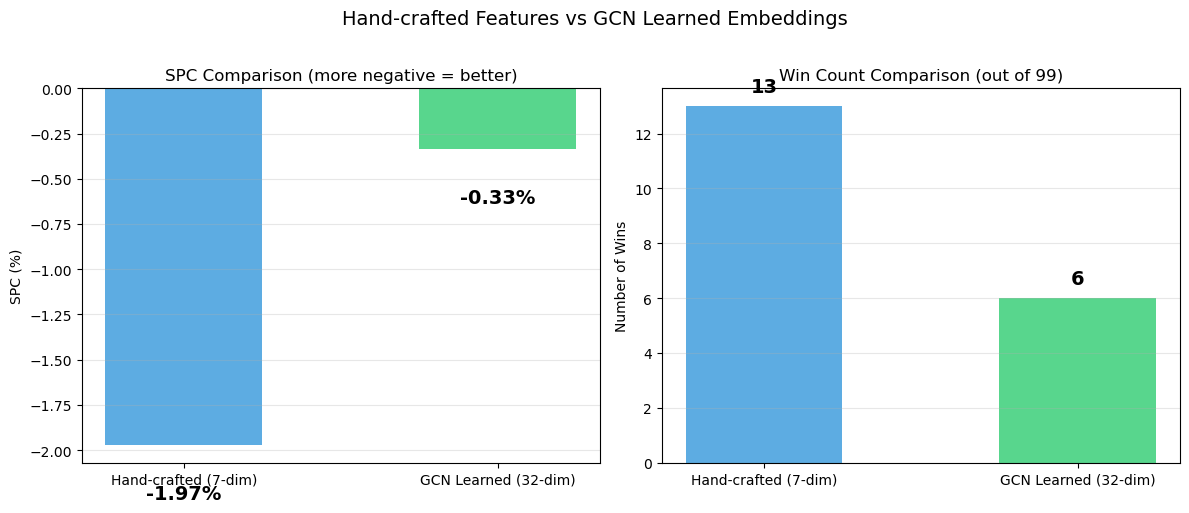

In [19]:
# Fill in your results from both runs:
comparison = {
    "Hand-crafted (7-dim)": {"spc": -1.97, "wins": 13, "ties": 86, "losses": 0},  # your previous result
    "GCN Learned (32-dim)": {"spc": spc, "wins": wins, "ties": ties, "losses": losses_count},  # current run
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SPC comparison
ax = axes[0]
methods = list(comparison.keys())
spc_vals = [comparison[m]["spc"] for m in methods]
colors = ["#3498db", "#2ecc71"]
bars = ax.bar(methods, spc_vals, color=colors, alpha=0.8, width=0.5)
for bar, val in zip(bars, spc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.3,
            f"{val:.2f}%", ha="center", fontsize=14, fontweight="bold")
ax.set_ylabel("SPC (%)")
ax.set_title("SPC Comparison (more negative = better)")
ax.axhline(y=0, color="black", linewidth=0.5)
ax.grid(axis="y", alpha=0.3)

# Wins comparison
ax = axes[1]
win_vals = [comparison[m]["wins"] for m in methods]
bars = ax.bar(methods, win_vals, color=colors, alpha=0.8, width=0.5)
for bar, val in zip(bars, win_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val}", ha="center", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Wins")
ax.set_title("Win Count Comparison (out of 99)")
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Hand-crafted Features vs GCN Learned Embeddings", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("comparison_handcrafted_vs_gcn.png", dpi=150, bbox_inches="tight")
plt.show()


#Sound Notification 
framerate = 44100
t = np.linspace(0, 1, framerate * 1)
data = np.sin(2 * np.pi * 440 * t) # 440Hz 音调
Audio(data, rate=framerate, autoplay=True)